# House Prices: first look

Competition: predict `SalePrice` for Ames, Iowa homes from 79 features.

**Scoring metric (check the Evaluation tab on Kaggle to confirm):** RMSE between `log(predicted price)` and `log(actual price)`. Practical consequences:
- Getting a $50k house wrong by $20k hurts as much as getting a $500k house wrong by $200k (it's relative error, not absolute).
- This is why almost every public solution trains on `log1p(SalePrice)` rather than raw price, and inverts with `expm1` at submission time.
- It also means we should evaluate our own CV score in log space, so it actually matches what the leaderboard rewards.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

In [2]:
train = pd.read_csv('../inputs/train.csv')
test = pd.read_csv('../inputs/test.csv')
print('train:', train.shape)
print('test:', test.shape)
train.head()

train: (1460, 81)
test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Note: test has one fewer column than train -- it's missing `SalePrice`, which is what we're predicting. `Id` is just a row identifier, not a feature.

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## Target: SalePrice

House prices are typically right-skewed (a few very expensive homes pull the mean up). Let's check, and compare to the log-transformed version.

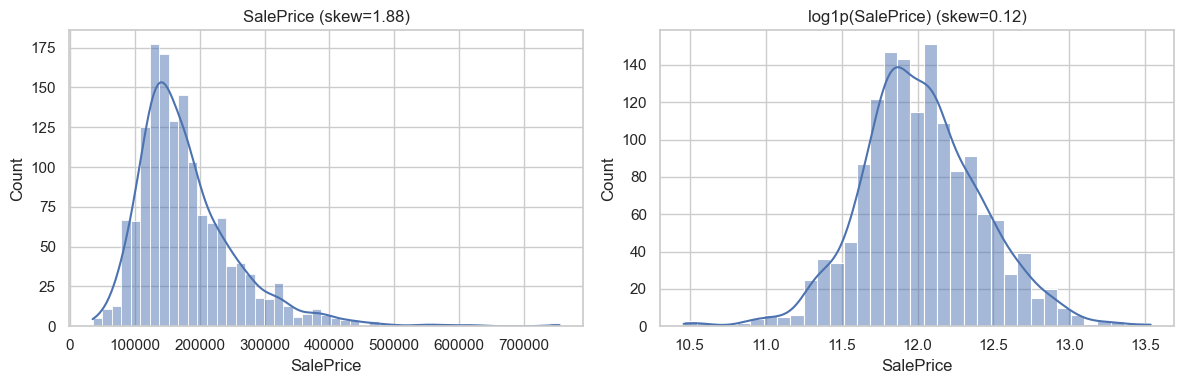

In [4]:
from scipy.stats import skew

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title(f"SalePrice (skew={skew(train['SalePrice']):.2f})")

log_price = np.log1p(train['SalePrice'])
sns.histplot(log_price, kde=True, ax=axes[1])
axes[1].set_title(f"log1p(SalePrice) (skew={skew(log_price):.2f})")
plt.tight_layout()

## Missing values

Important Ames-dataset quirk: for many categorical columns (`PoolQC`, `Alley`, `BsmtQual`, `GarageType`, ...), `NA` doesn't mean "missing data" -- per `data_description.txt` it means "feature doesn't exist on this house" (e.g. no pool). Pandas' default CSV reading happens to read these as actual `NaN`, so we have to treat them differently from genuinely missing data (like a handful of `Electrical` or `LotFrontage` values that really are unknown).

In [5]:
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)
pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})

,n_missing,pct_missing
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


## Correlation with SalePrice

Quick numeric-only scan to see what's worth digging into first. Tree models don't need this, but it's a fast sanity check and matters a lot for linear baselines.

In [6]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr = train[numeric_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
corr.head(15)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64

## Correlation for categorical / boolean features

The scan above only looked at numeric columns, but ~44 of the 79 features are categorical (`object` dtype). A plain Pearson correlation coefficient assumes both variables are numeric *and* that "bigger number" means "more of something" for both -- so it behaves differently depending on the variable type:

- **Boolean / binary (0/1):** Pearson is perfectly valid here -- it even has its own name, *point-biserial correlation*, and is mathematically identical to the usual formula. It answers "does the group coded 1 have systematically higher/lower values than the group coded 0?"
- **Ordinal categorical** (has a real order, e.g. `ExterQual`: Po < Fa < TA < Gd < Ex): valid *if* you map categories to integers that respect that order first. Then Pearson/Spearman is meaningful.
- **Nominal categorical** (no order, e.g. `Neighborhood`, `GarageType`): Pearson is **not** meaningful. If you label-encode a nominal column (e.g. via `factorize`), the resulting "correlation" just reflects the arbitrary order pandas happened to assign the categories -- that's noise, not signal. Two better statistics, both scaled 0-1:
  - categorical vs. categorical -> **Cramér's V** (built from a chi-square test of independence).
  - categorical vs. numeric -> **correlation ratio (η)** -- the fraction of the numeric variable's variance explained by category membership (same idea as R² from a one-way ANOVA).

Both of those are *unsigned* -- strength of association only, no direction. That's inherent to nominal categories: `GarageType == Detchd` isn't "high" or "low", so "positive/negative" has no meaning for it.

One dataset-specific caveat: `PoolQC`, `Alley`, `Fence`, `MiscFeature` are NaN for almost every house (NaN = "doesn't have this feature", see the missing-values section above). Both statistics drop those NaN rows, so e.g. `PoolQC`'s association numbers come from ~7 houses and should be read as noisy, not reliable.

To see everything at once, we build a full association matrix (Pearson / Cramér's V / η depending on the pair) across all ~80 features and plot it as one heatmap, with rows/columns reordered by hierarchical clustering so related features sit next to each other -- in CSV column order, an 80x80 grid is close to unreadable.

In [7]:
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform


def cramers_v(a, b):
    """Association strength (0-1) between two categorical variables."""
    ct = pd.crosstab(a, b)
    if min(ct.shape) < 2:
        return np.nan
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    phi2_corr = max(0, chi2 / n - (r - 1) * (k - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(r_corr - 1, k_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else np.nan


def correlation_ratio(categories, values):
    """Association strength (0-1) between a categorical and a numeric variable."""
    df = pd.DataFrame({'cat': categories, 'val': values}).dropna()
    if df['cat'].nunique() < 2:
        return np.nan
    grand_mean = df['val'].mean()
    ss_between = df.groupby('cat')['val'].apply(lambda g: len(g) * (g.mean() - grand_mean) ** 2).sum()
    ss_total = ((df['val'] - grand_mean) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan

C:\Users\Bob\AppData\Local\Temp\ipykernel_8852\540870734.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = set(assoc_df.select_dtypes(include=['object']).columns)


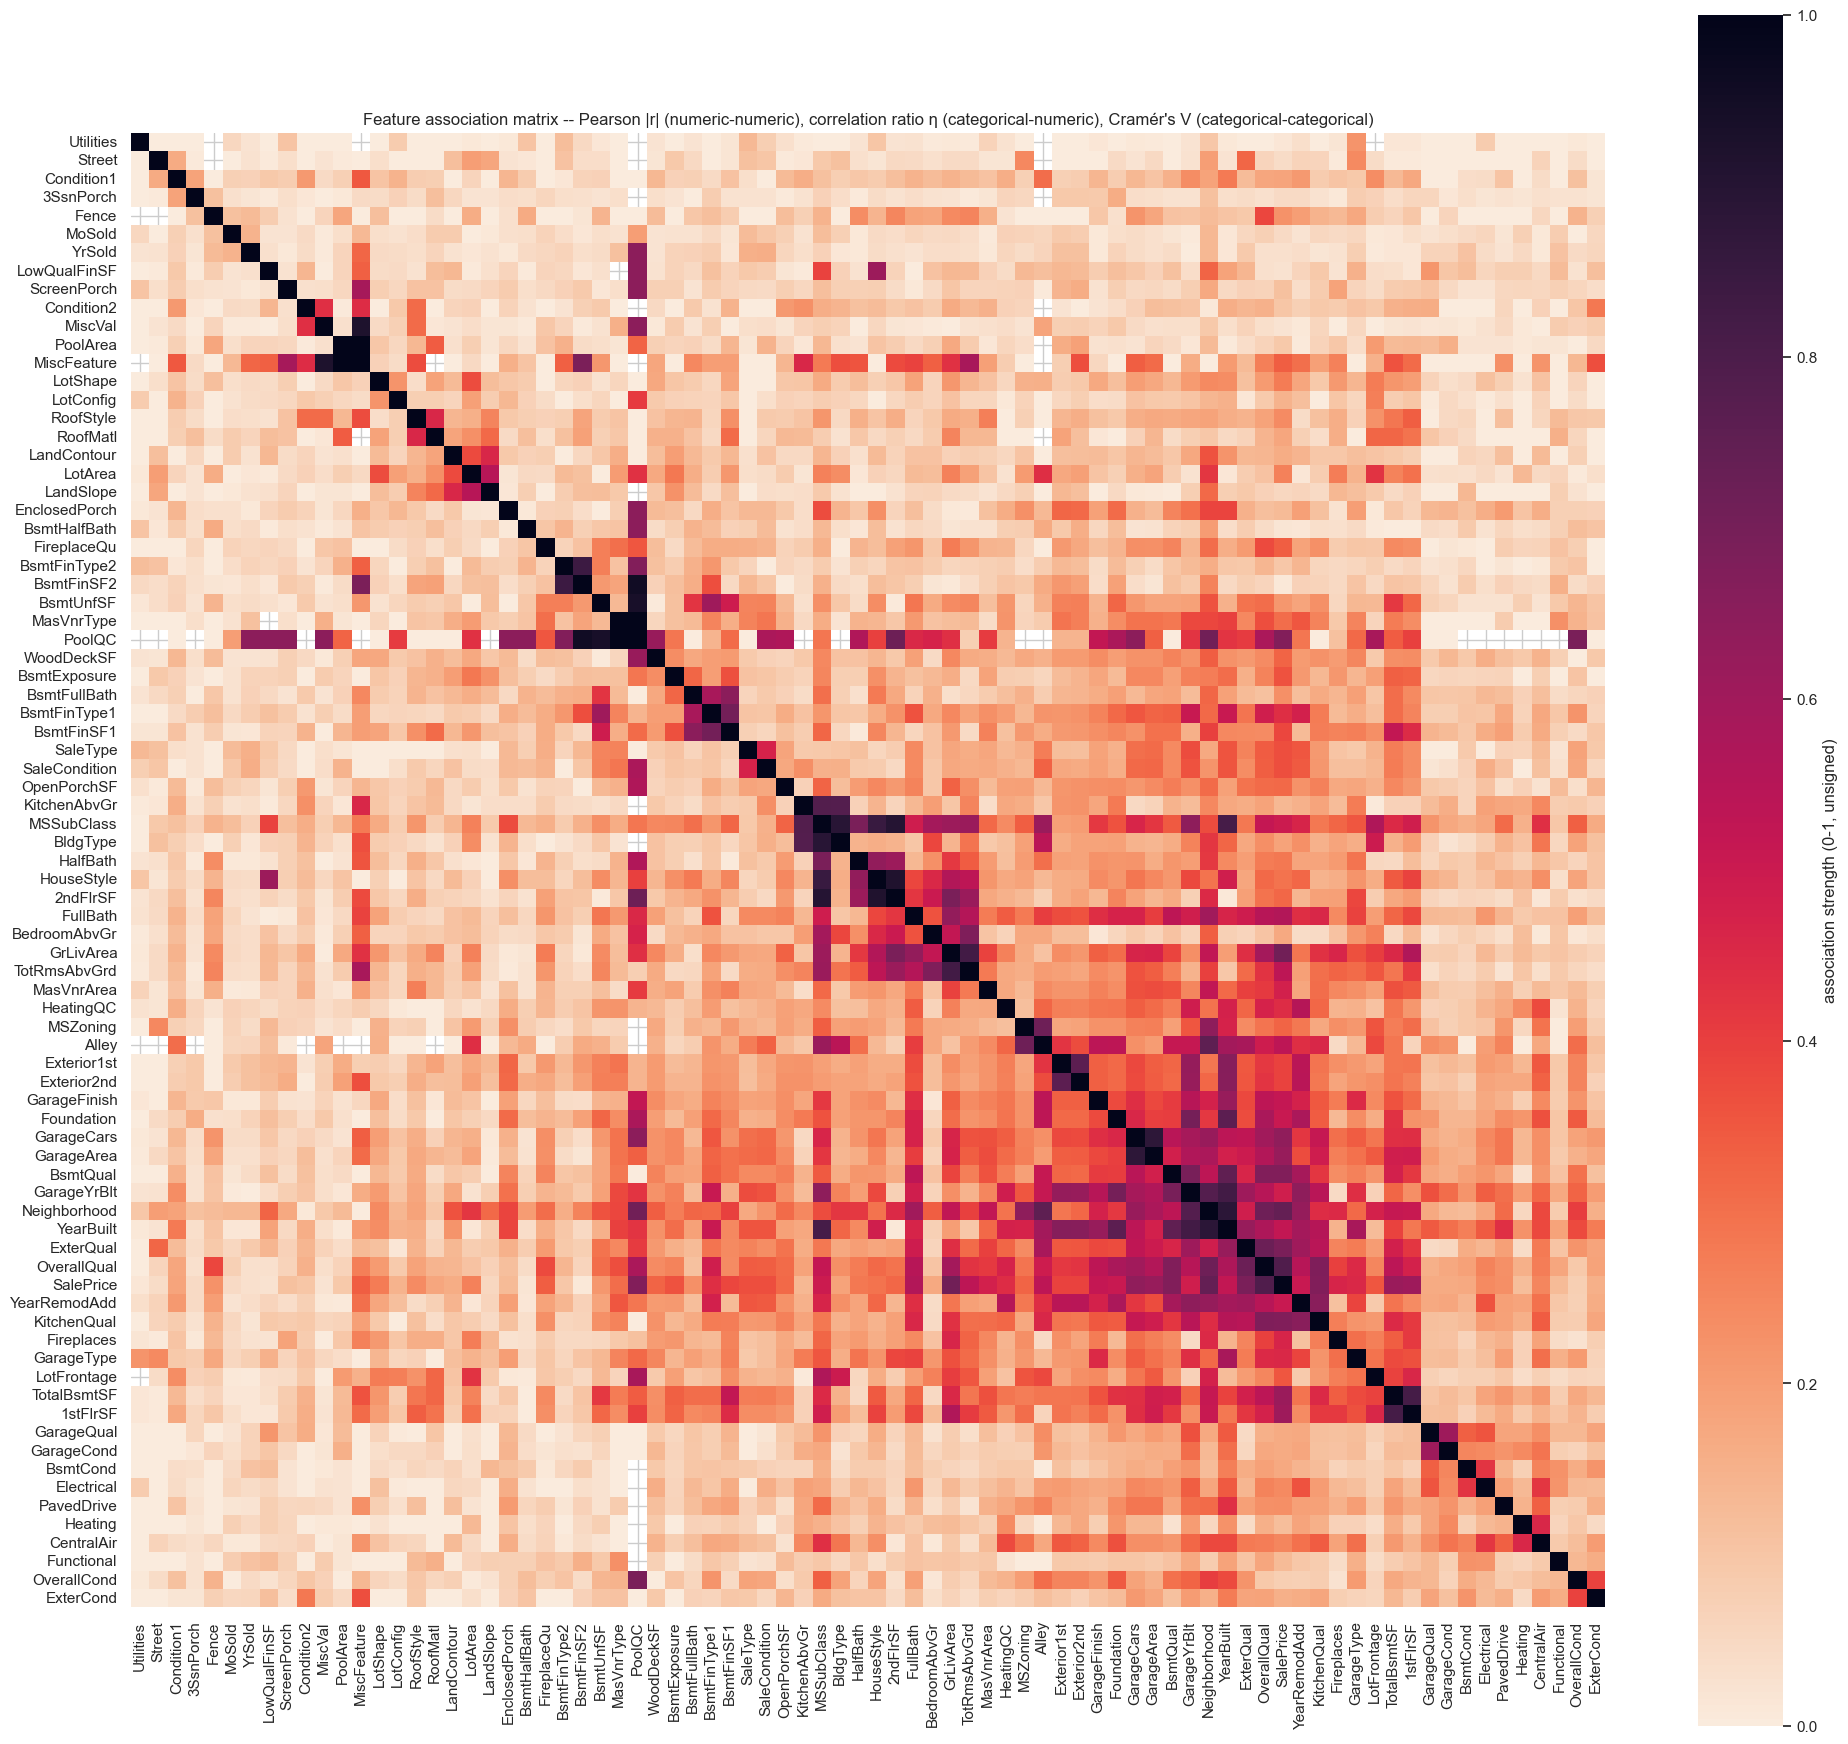

In [8]:
# MSSubClass is stored as an int but is really a nominal category code (see
# data_description.txt) -- treat it as categorical rather than numeric here.
assoc_df = train.drop(columns=['Id']).copy()
assoc_df['MSSubClass'] = assoc_df['MSSubClass'].astype(str)

features = assoc_df.columns
cat_cols = set(assoc_df.select_dtypes(include=['object']).columns)
num_cols = set(features) - cat_cols

assoc = pd.DataFrame(np.nan, index=features, columns=features, dtype=float)
for i, c1 in enumerate(features):
    for c2 in features[i:]:
        if c1 in num_cols and c2 in num_cols:
            val = abs(assoc_df[c1].corr(assoc_df[c2]))
        elif c1 in cat_cols and c2 in cat_cols:
            val = cramers_v(assoc_df[c1], assoc_df[c2])
        else:
            cat_col, num_col = (c1, c2) if c1 in cat_cols else (c2, c1)
            val = correlation_ratio(assoc_df[cat_col], assoc_df[num_col])
        assoc.loc[c1, c2] = assoc.loc[c2, c1] = val
for c in features:
    assoc.loc[c, c] = 1.0

# Cluster so related features sit next to each other -- in raw column order,
# 80 features make the heatmap unreadable.
dist = 1 - assoc.fillna(0)
dist = (dist + dist.T) / 2
for c in features:
    dist.loc[c, c] = 0.0
order = leaves_list(linkage(squareform(dist.values, checks=False), method='average'))
ordered = assoc.columns[order]

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(assoc.loc[ordered, ordered], cmap='rocket_r', vmin=0, vmax=1, square=True,
            cbar_kws={'label': 'association strength (0-1, unsigned)'}, ax=ax)
ax.set_title(
    "Feature association matrix -- Pearson |r| (numeric-numeric), "
    "correlation ratio \u03b7 (categorical-numeric), Cram\u00e9r's V (categorical-categorical)"
)
plt.tight_layout()

In [9]:
# Same payoff as the numeric-only scan above, but now categorical features can
# show up too -- e.g. Neighborhood and quality-grade columns rank highly.
assoc['SalePrice'].drop('SalePrice').sort_values(ascending=False).head(15)

OverallQual     0.790982
Neighborhood    0.738630
GrLivArea       0.708624
ExterQual       0.690933
KitchenQual     0.675721
BsmtQual        0.673614
PoolQC          0.669814
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
Alley           0.534319
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

## Known outlier check: GrLivArea

The dataset's original author (Dean De Cock) explicitly calls out a handful of houses with very large `GrLivArea` that sold cheaply -- likely partial sales or data issues -- and recommends removing them from training. Worth confirming on our copy before we blindly drop anything.

,Id,GrLivArea,SalePrice,SaleCondition
523,524,4676,184750,Partial
691,692,4316,755000,Normal
1182,1183,4476,745000,Abnorml
1298,1299,5642,160000,Partial


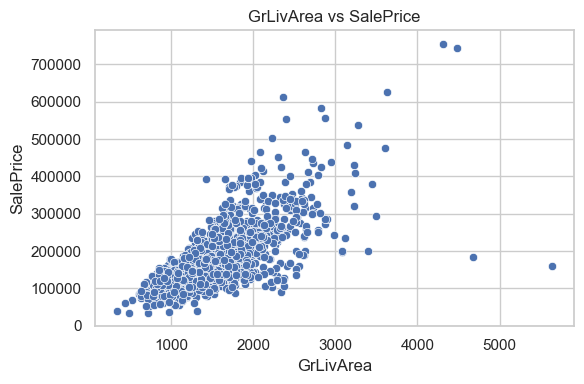

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', ax=ax)
ax.set_title('GrLivArea vs SalePrice')
plt.tight_layout()

train.loc[train['GrLivArea'] > 4000, ['Id', 'GrLivArea', 'SalePrice', 'SaleCondition']]

## Next steps

1. Decide on a cross-validation scheme (plain K-fold is fine here -- no obvious time leakage to worry about despite `YrSold`/`MoSold` columns, but worth a second look later).
2. Build the simplest possible baseline (e.g. linear regression on a few features, or even just reproduce `sample_submission.csv`'s approach) and submit it to get on the leaderboard early.
3. Then iterate: missing value handling (NA-means-absent vs. truly-missing), categorical encoding, skewed-feature transforms, regularized linear models, then gradient boosting.